In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("online_retail_II.csv")

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.shape

(1067371, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [6]:
df.isnull().sum()


Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

# DATA CLEANING

Convert InvoiceDate

In [7]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

Select United Kingdom

In [8]:
df = df[df["Country"] == "United Kingdom"]

In [9]:
df.shape

(981330, 8)

Remove Missing Customer ID

In [10]:
df = df.dropna(subset=["Customer ID"])

df.shape

(741301, 8)

Remove Negative Price

In [11]:
df = df[df["Price"] > 0]

# Create Total Price

In [12]:
df["TotalPrice"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


# EDA

Quantity Histogram

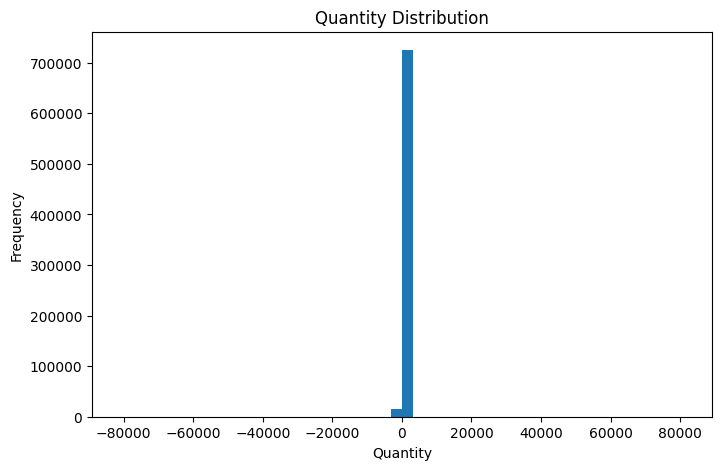

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["Quantity"], bins=50)

plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Quantity Distribution")

plt.show()

Price Histogram

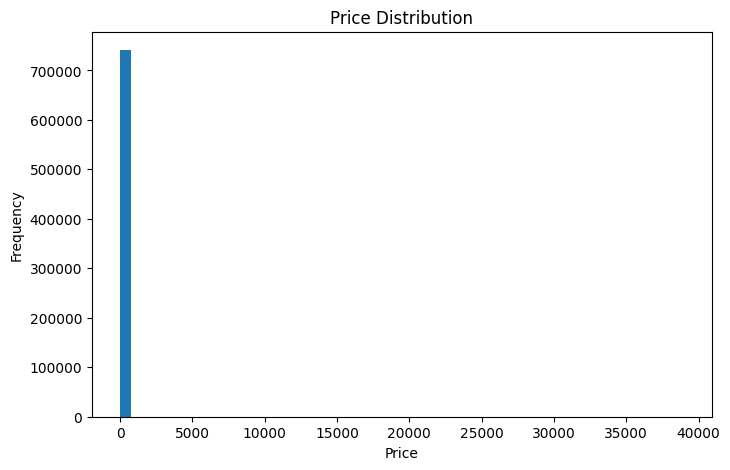

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=50)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")

plt.show()


Total Price Histogram

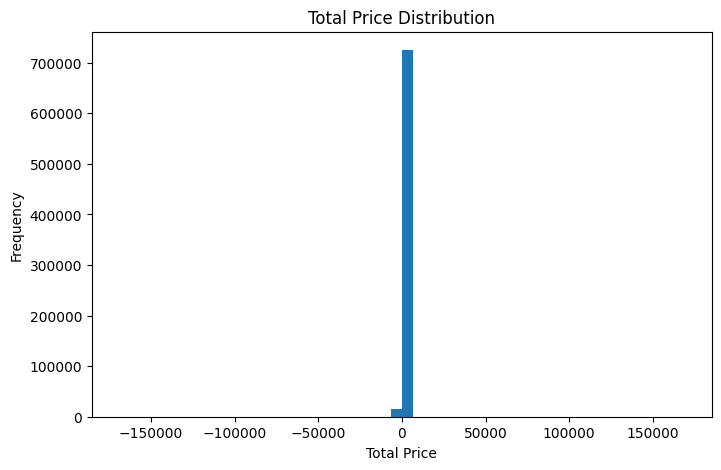

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df["TotalPrice"], bins=50)

plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.title("Total Price Distribution")

plt.show()

# CUSTOMER ANALYSIS

Total Spend per Customer

In [16]:
customer_spend = df.groupby(
    "Customer ID"
)["TotalPrice"].sum()

customer_spend.head()

Customer ID
12346.0     -64.68
12608.0     415.79
12745.0     723.85
12746.0     230.85
12747.0    9164.59
Name: TotalPrice, dtype: float64

Top 10 Customers

In [17]:
customer_spend.sort_values(
    ascending=False
).head(10)

Customer ID
18102.0    598215.22
17450.0    233579.39
13694.0    190825.52
17511.0    171885.98
16684.0    141502.25
15061.0    136391.48
15311.0    113513.07
13089.0    113214.19
17949.0     98895.59
16029.0     91800.91
Name: TotalPrice, dtype: float64

Number of Orders per Customer

In [18]:
customer_orders = df.groupby(
    "Customer ID"
)["Invoice"].nunique()

customer_orders.head()

Customer ID
12346.0    17
12608.0     1
12745.0     2
12746.0     3
12747.0    32
Name: Invoice, dtype: int64

# RFM

Find Latest Date

In [19]:
latest_date = df["InvoiceDate"].max()

print(latest_date)

2011-12-09 12:49:00


# Create Reference Date

In [20]:
reference_date = latest_date + pd.Timedelta(days=1)

print(reference_date)

2011-12-10 12:49:00


# Create Recency

In [21]:
recency = df.groupby(
    "Customer ID"
)["InvoiceDate"].max()

recency = (
    reference_date - recency
).dt.days

recency.head()

Customer ID
12346.0    326
12608.0    405
12745.0    487
12746.0    528
12747.0      2
Name: InvoiceDate, dtype: int64

# Create Frequency

In [22]:
frequency = df.groupby(
    "Customer ID"
)["Invoice"].nunique()

frequency.head()

Customer ID
12346.0    17
12608.0     1
12745.0     2
12746.0     3
12747.0    32
Name: Invoice, dtype: int64

# Create Monetary

In [23]:
monetary = df.groupby(
    "Customer ID"
)["TotalPrice"].sum()

monetary.head()

Customer ID
12346.0     -64.68
12608.0     415.79
12745.0     723.85
12746.0     230.85
12747.0    9164.59
Name: TotalPrice, dtype: float64

# Create RFM DataFrame


In [24]:
rfm = pd.DataFrame()

rfm["Recency"] = recency
rfm["Frequency"] = frequency
rfm["Monetary"] = monetary

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,17,-64.68
12608.0,405,1,415.79
12745.0,487,2,723.85
12746.0,528,3,230.85
12747.0,2,32,9164.59


RFM Statistics

In [25]:
rfm.describe()

,Recency,Frequency,Monetary
count,5407.000000,5407.000000,5407.000000
mean,204.640466,7.490290,2553.434997
std,212.331114,14.571213,11348.512485
min,1.000000,1.000000,-25111.090000
25%,25.000000,2.000000,314.705000
50%,99.000000,4.000000,815.900000
75%,383.000000,8.000000,2111.485000
max,739.000000,364.000000,598215.220000


# OUTLIERS

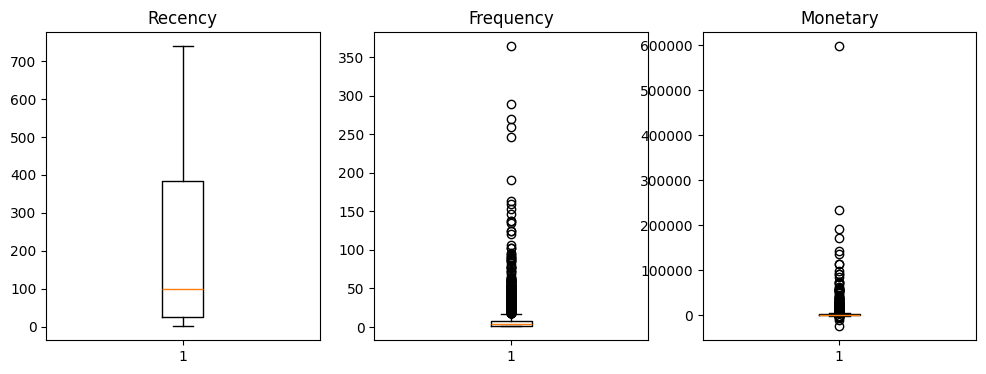

In [26]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.boxplot(rfm["Recency"])
plt.title("Recency")

plt.subplot(1,3,2)
plt.boxplot(rfm["Frequency"])
plt.title("Frequency")

plt.subplot(1,3,3)
plt.boxplot(rfm["Monetary"])
plt.title("Monetary")

plt.show()

IQR Outlier Capping

In [27]:
for col in ["Recency", "Frequency", "Monetary"]:
    
    Q1 = rfm[col].quantile(0.25)
    Q3 = rfm[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    upper = Q3 + 3 * IQR
    
    rfm[col] = rfm[col].clip(
        upper=upper
    )

print("Outliers handled")

Outliers handled


# LOG TRANSFORMATION

Log Transform Frequency

In [28]:
rfm["Frequency"] = np.log1p(
    rfm["Frequency"]
)

Log Transform Monetary

In [29]:
rfm["Monetary"] = np.log1p(
    rfm["Monetary"]
)

C:\Users\red\AppData\Roaming\Python\Python314\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


# SCALING

In [30]:
X = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
]

Standard Scaling

In [31]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [32]:
X_scaled[:5]

array([[ 0.5716108 ,  1.56223928,         nan],
       [ 0.94370562, -1.17033643, -0.51917559],
       [ 1.32993061, -0.66608023, -0.098407  ],
       [ 1.52304311, -0.30830477, -0.96511936],
       [-0.95444894,  2.06649547,  1.6786029 ]])

# K-MEANS

Elbow Method

In [33]:
print(rfm.isnull().sum())

Recency       0
Frequency     0
Monetary     78
dtype: int64


print(rfm.isnull().sum())

In [34]:
rfm = rfm.dropna(
    subset=["Recency", "Frequency", "Monetary"]
)

In [35]:
print(rfm.isnull().sum())

Recency      0
Frequency    0
Monetary     0
dtype: int64


In [36]:
X = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
]

In [37]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [38]:
inertia = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

print(inertia)

[7690.635540410187, 5004.886805388297, 3897.682132619597, 3099.456432253348, 2716.8612535257307, 2417.6244202703037, 2179.490387472057, 1997.439346042065, 1833.5234550788293]


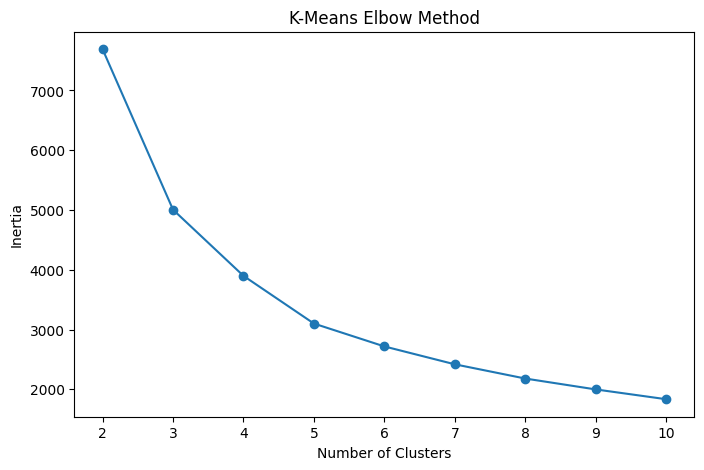

In [39]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")

plt.show()

K-Means Model

In [40]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(
    X_scaled
)

Add Cluster

In [41]:
rfm["KMeans_Cluster"] = kmeans_labels

rfm.head()

,Recency,Frequency,Monetary,KMeans_Cluster
Customer ID,,,,
12608.0,405,0.693147,6.032582,0
12745.0,487,1.098612,6.585965,0
12746.0,528,1.386294,5.446091,0
12747.0,2,3.295837,8.923035,2
12748.0,1,3.295837,8.923035,2


Cluster Count

In [42]:
rfm["KMeans_Cluster"].value_counts()

KMeans_Cluster
1    1674
0    1385
2    1164
3    1106
Name: count, dtype: int64

# Silhouette Score

In [43]:
silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

print(
    "Silhouette Score:",
    silhouette
)

Silhouette Score: 0.3750052926653729


K-Means Graph

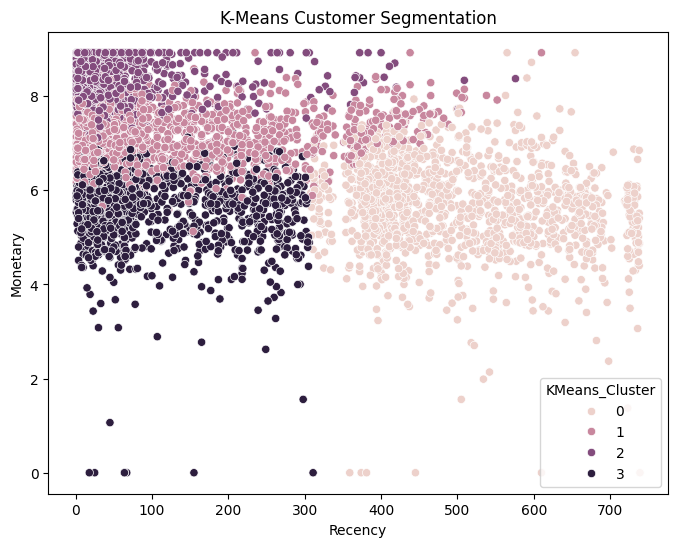

In [44]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="KMeans_Cluster"
)

plt.title("K-Means Customer Segmentation")

plt.show()

K-Means Cluster Profile

In [45]:
rfm.groupby(
    "KMeans_Cluster"
)[
    ["Recency", "Frequency", "Monetary"]
].mean()

,Recency,Frequency,Monetary
KMeans_Cluster,,,
0,499.306137,0.975949,5.672727
1,118.013740,1.807290,7.138973
2,44.498282,2.838733,8.405836
3,110.245027,0.974334,5.600845


# HIERARCHICAL CLUSTERING

Dendrogram

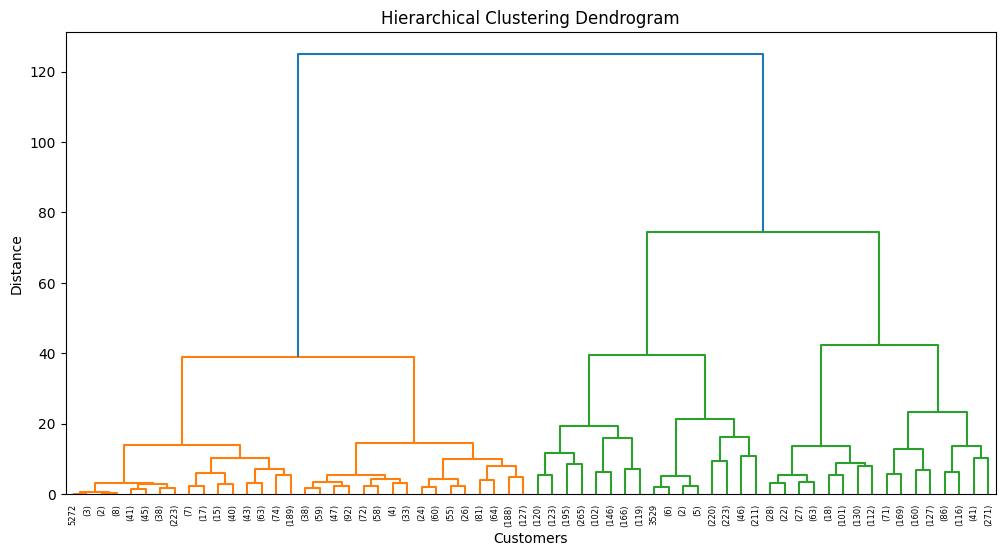

In [46]:
linked = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(12,6))

dendrogram(
    linked,
    truncate_mode="level",
    p=5
)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

Hierarchical Model

In [47]:
hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(
    X_scaled
)

Add Hierarchical Cluster

In [48]:
rfm["Hierarchical_Cluster"] = (
    hierarchical_labels
)

rfm.head()

,Recency,Frequency,Monetary,KMeans_Cluster,Hierarchical_Cluster
Customer ID,,,,,
12608.0,405,0.693147,6.032582,0,2
12745.0,487,1.098612,6.585965,0,3
12746.0,528,1.386294,5.446091,0,2
12747.0,2,3.295837,8.923035,2,1
12748.0,1,3.295837,8.923035,2,1


Hierarchical Silhouette

In [49]:
hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print(
    "Hierarchical Silhouette Score:",
    hierarchical_silhouette
)

Hierarchical Silhouette Score: 0.38035268931685123


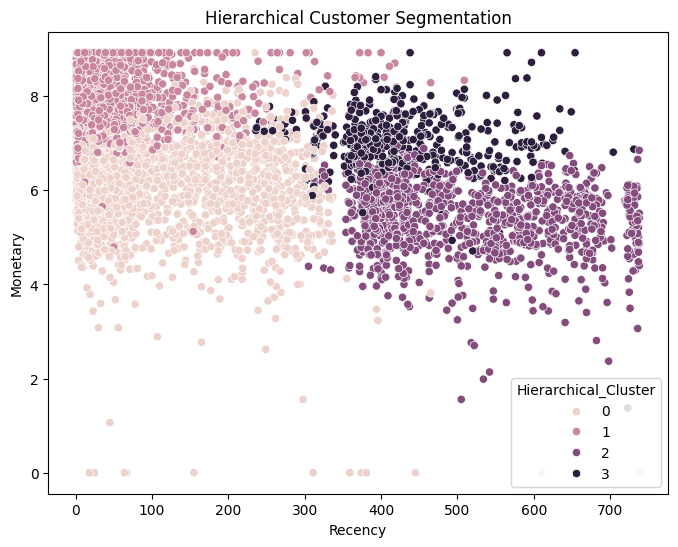

In [50]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Hierarchical_Cluster"
)

plt.title(
    "Hierarchical Customer Segmentation"
)

plt.show()

# DBSCAN

In [51]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    X_scaled
)

Add DBSCAN Cluster

In [52]:
rfm["DBSCAN_Cluster"] = (
    dbscan_labels
)

rfm.head()

,Recency,Frequency,Monetary,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster
Customer ID,,,,,,
12608.0,405,0.693147,6.032582,0,2,0
12745.0,487,1.098612,6.585965,0,3,1
12746.0,528,1.386294,5.446091,0,2,1
12747.0,2,3.295837,8.923035,2,1,1
12748.0,1,3.295837,8.923035,2,1,1


Check DBSCAN Clusters

In [53]:
rfm["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
 1    4015
 0    1271
-1      29
 2       6
 3       5
 4       3
Name: count, dtype: int64

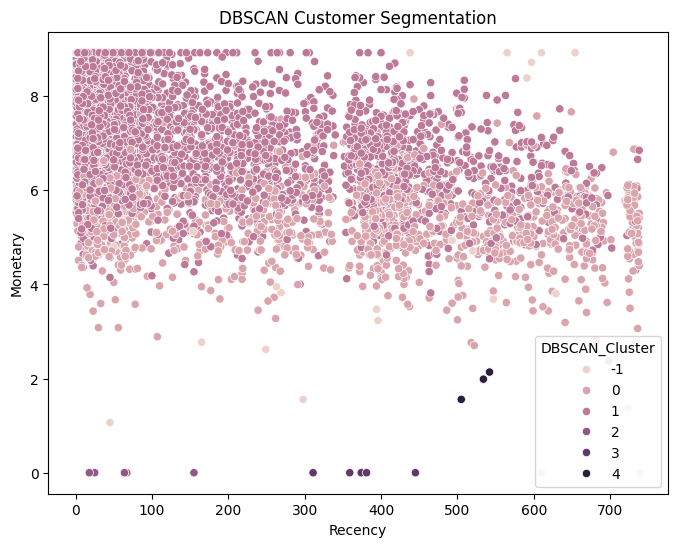

In [54]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="DBSCAN_Cluster"
)

plt.title(
    "DBSCAN Customer Segmentation"
)

plt.show()

# Compare All Algorithms

In [55]:
print(
    "K-Means Silhouette:",
    silhouette_score(
        X_scaled,
        kmeans_labels
    )
)

print(
    "Hierarchical Silhouette:",
    silhouette_score(
        X_scaled,
        hierarchical_labels
    )
)

K-Means Silhouette: 0.3750052926653729
Hierarchical Silhouette: 0.38035268931685123


In [56]:
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) >= 2:
    
    print(
        "DBSCAN Silhouette:",
        silhouette_score(
            X_scaled[mask],
            dbscan_labels[mask]
        )
    )
else:
    print(
        "DBSCAN has fewer than 2 valid clusters"
    )

DBSCAN Silhouette: 0.2987035110338516


# Final RFM Dataset

In [57]:
rfm.head()

,Recency,Frequency,Monetary,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster
Customer ID,,,,,,
12608.0,405,0.693147,6.032582,0,2,0
12745.0,487,1.098612,6.585965,0,3,1
12746.0,528,1.386294,5.446091,0,2,1
12747.0,2,3.295837,8.923035,2,1,1
12748.0,1,3.295837,8.923035,2,1,1
